In [ ]:
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV


In [2]:

# 1. Load the California Housing Dataset
data = fetch_california_housing()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target



In [3]:
# 2. Check for missing values
print("Missing values in features:\n", X.isnull().sum())
print("Missing values in target:", pd.isnull(y).sum())


Missing values in features:
 MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
dtype: int64
Missing values in target: 0


In [4]:
# 3. Split the data (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [5]:


# 1. Initialize the models
xgb_model = XGBRegressor(random_state=42)  # Default hyperparameters
ada_model = AdaBoostRegressor(random_state=42)

# 2. Train the models
xgb_model.fit(X_train_scaled, y_train)
ada_model.fit(X_train_scaled, y_train)

# 3. Predict on the test set
xgb_preds = xgb_model.predict(X_test_scaled)
ada_preds = ada_model.predict(X_test_scaled)

# 4. Evaluate performance
xgb_rmse = mean_squared_error(y_test, xgb_preds, squared=False)
xgb_r2 = r2_score(y_test, xgb_preds)

ada_rmse = mean_squared_error(y_test, ada_preds, squared=False)
ada_r2 = r2_score(y_test, ada_preds)

# 5. Print the results
print("XGBoost Performance:")
print(f"  RMSE: {xgb_rmse:.4f}")
print(f"  R^2 Score: {xgb_r2:.4f}\n")

print("AdaBoost Performance:")
print(f"  RMSE: {ada_rmse:.4f}")
print(f"  R^2 Score: {ada_r2:.4f}")


XGBoost Performance:
  RMSE: 0.4718
  R^2 Score: 0.8301

AdaBoost Performance:
  RMSE: 0.7839
  R^2 Score: 0.5311


c:\Users\hwi\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\hwi\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [ ]:

def print_metrics(y_true, y_pred, model_name):
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    r2  = r2_score(y_true, y_pred)
    print(f"\n{model_name} Performance:")
    print(f"  MSE  = {mse:.4f}")
    print(f"  MAE  = {mae:.4f}")
    print(f"  R²   = {r2:.4f}")


print_metrics(y_test, xgb_preds, "XGBoost")
print_metrics(y_test, ada_preds, "AdaBoost")



XGBoost Performance:
  MSE  = 0.2226
  MAE  = 0.3096
  R²   = 0.8301

AdaBoost Performance:
  MSE  = 0.6145
  MAE  = 0.6498
  R²   = 0.5311


In [ ]:
xgb = XGBRegressor(objective='reg:squarederror', random_state=42)


param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.9, 1.0]
}


grid_search = GridSearchCV(estimator=xgb, param_grid=param_grid,
                           cv=5, scoring='neg_root_mean_squared_error',
                           verbose=1, n_jobs=-1)


grid_search.fit(X_train, y_train)


best_xgb = grid_search.best_estimator_


y_pred = best_xgb.predict(X_test)


mse = mean_squared_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred, squared=False)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)


print(" Best Parameters:", grid_search.best_params_)
print(" RMSE:", rmse)
print(" MSE:", mse)
print(" MAE:", mae)
print(" R² Score:", r2)


Fitting 5 folds for each of 243 candidates, totalling 1215 fits


🔝 Top 5 Features:
MedInc: 0.3681
Longitude: 0.1546
Latitude: 0.1371
AveOccup: 0.1133
AveRooms: 0.0970


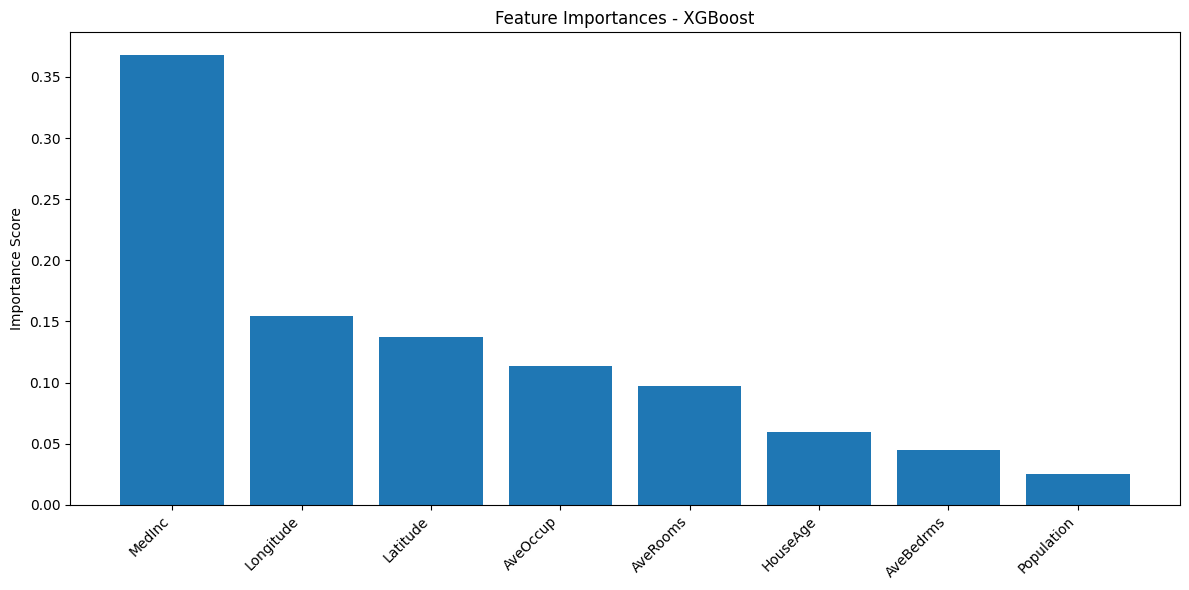

In [ ]:
importances = best_xgb.feature_importances_


feature_names = X.columns  


indices = np.argsort(importances)[::-1]


top_features = [(feature_names[i], importances[i]) for i in indices[:5]]
print("🔝 Top 5 Features:")
for name, score in top_features:
    print(f"{name}: {score:.4f}")


plt.figure(figsize=(12, 6))
plt.title("Feature Importances - XGBoost")
plt.bar(range(len(importances)), importances[indices], align='center')
plt.xticks(range(len(importances)), feature_names[indices], rotation=45, ha='right')
plt.ylabel("Importance Score")
plt.tight_layout()
plt.show()
